In [1]:
import scarf
import scarf.plotting as splt

scarf.fetch_dataset(
    "tenx_5K_pbmc_rnaseq",
    save_path="scarf_datasets",
    as_zarr=True,
)
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'RNA_tSNE1', 'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 
            'RNA_cluster', 'RNA_UMAP2', 'RNA_UMAP1'
   RNA assay has 13632 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs'

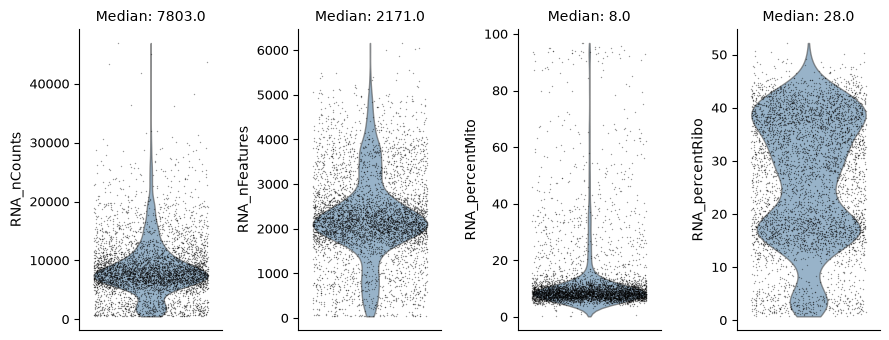

In [2]:
qc_cols = [
    c
    for c in ("RNA_nCounts", "RNA_nFeatures", "RNA_percentMito", "RNA_percentRibo")
    if c in ds.cells.columns
]
qc_df = ds.cells.to_pandas_dataframe(qc_cols)
qc_df["groups"] = 0
splt.qc(qc_df)

597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



612 cells flagged for filtering out using attribute RNA_percentMito



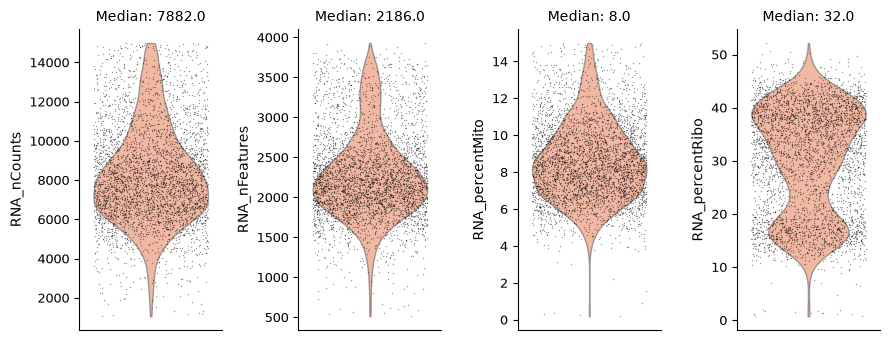

In [3]:
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
qc_df = ds.cells.to_pandas_dataframe(qc_cols)
qc_df["groups"] = 0
qc_df = qc_df.reindex(ds.cells.active_index("I"))
splt.qc(qc_df, color="coral")

190 cells flagged for filtering out using attribute RNA_nCounts



137 cells flagged for filtering out using attribute RNA_nFeatures



215 cells flagged for filtering out using attribute RNA_percentMito



0 cells flagged for filtering out using attribute RNA_percentRibo



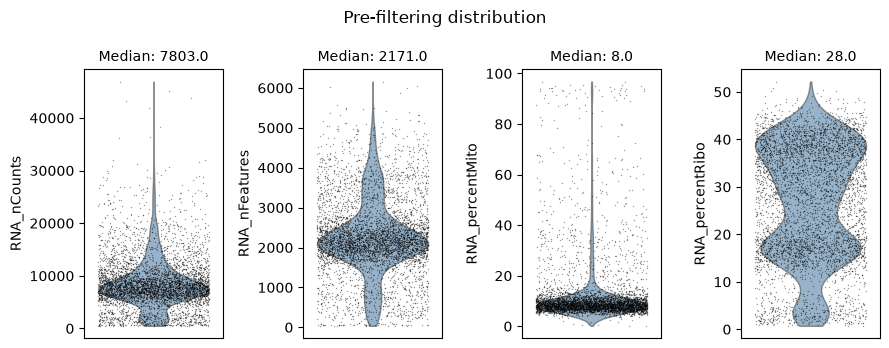

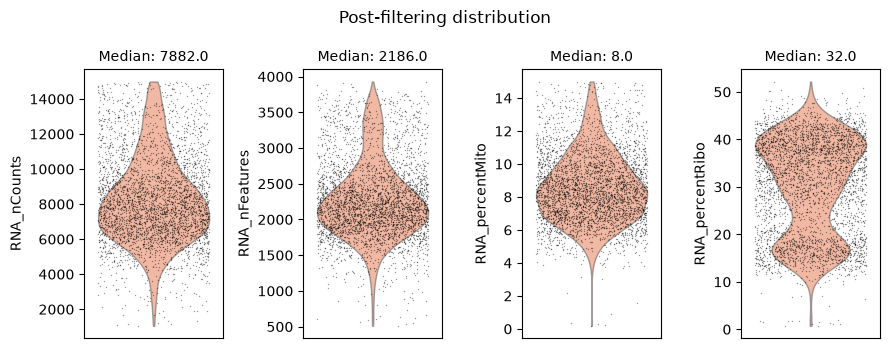

In [4]:
ds_auto = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds_auto.auto_filter_cells(show_qc_plots=True)

Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



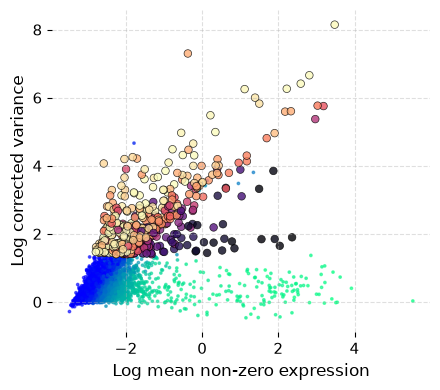

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.4s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

Simulated 3940 synthetic doublets



0 features missing in target data



Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__15__I/ann__l2__50__50__48__4466



Doublet scores stored in cell metadata column 'RNA_doublet_score'



Training UMAP:   0%|                                                                                          …

In [5]:
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)
ds.run_leiden_clustering(resolution=0.5)
ds.run_doublet_detection(cluster_key="RNA_leiden_cluster")
ds.run_umap(n_epochs=100, spread=5, min_dist=1, parallel=True)

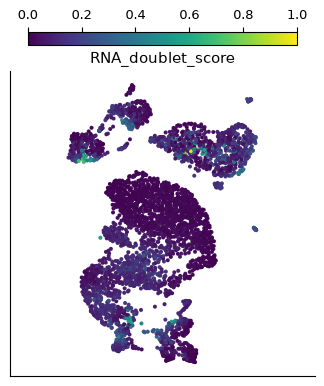

In [6]:
score_col = [c for c in ds.cells.columns if c.endswith("doublet_score")][0]
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by=score_col,
    show=False,
).figure

In [7]:
ds.cells.to_pandas_dataframe(columns=[score_col], key="I").describe()

,RNA_doublet_score
count,3940.000000
mean,0.081811
std,0.099350
min,0.000000
25%,0.015048
50%,0.052282
75%,0.114982
max,1.000000
